# Stage 3 - Model Development

We now train and compare churn models. The goals:

1. Beat a simple baseline.
2. Compare Logistic Regression, Random Forest, and XGBoost.
3. Compare three ways of handling the class imbalance: original distribution,
   class weights, and SMOTE - all leakage-safe inside an `imblearn` pipeline.
4. Choose a model using **PR-AUC** (primary) and **precision at 80% recall**
   (tie-breaker), not accuracy.
5. Pick a decision threshold that catches ~80% of churners (recall-leaning).
6. Touch the test set only once, after every decision is made.

All logic lives in `src/models/`; this notebook calls it and records decisions.

In [1]:
import sys
from pathlib import Path

here = Path.cwd()
project_root = here if (here / "src").exists() else here.parent
sys.path.insert(0, str(project_root))

import json
import warnings

import numpy as np
import pandas as pd
from sklearn.base import clone

from src.config import DATA_PROCESSED_DIR, MODELS_DIR, FIGURES_DIR
from src.data.split import split_data
from src.models import train, evaluate

# The dummy baseline predicts the base rate, which makes precision undefined in
# some folds; that warning is expected and not a problem.
warnings.filterwarnings("ignore", message="Precision is ill-defined")
pd.set_option("display.max_columns", None)

TARGET_RECALL = 0.80

df = pd.read_csv(DATA_PROCESSED_DIR / "telco_clean.csv")
split = split_data(df)

# XGBoost uses this churn-to-stay ratio when class weighting is turned on.
pos_weight = (split.y_train == 0).sum() / (split.y_train == 1).sum()
print("Train churn-to-stay ratio (pos_weight):", round(pos_weight, 3))
print("Split sizes:", len(split.X_train), len(split.X_val), len(split.X_test))

Train churn-to-stay ratio (pos_weight): 2.769
Split sizes: 4225 1409 1409


## 1. Compare every model and imbalance strategy with cross-validation

In [2]:
# Build the comparison: dummy baseline plus each model under each imbalance
# strategy. Cross-validation runs on the TRAINING set only.
candidates = [("dummy", "original")]
for model_name in ["logistic", "random_forest", "xgboost"]:
    for strategy in train.IMBALANCE_STRATEGIES:
        candidates.append((model_name, strategy))

records = []
for model_name, strategy in candidates:
    pipeline = train.make_candidate(model_name, strategy, pos_weight)
    scores = train.cross_validate_model(pipeline, split.X_train, split.y_train)
    records.append(
        {
            "model": model_name,
            "strategy": strategy,
            "pr_auc": scores["pr_auc"]["mean"],
            "roc_auc": scores["roc_auc"]["mean"],
            "recall": scores["recall"]["mean"],
            "precision": scores["precision"]["mean"],
            "f1": scores["f1"]["mean"],
        }
    )

results = pd.DataFrame(records)
results.round(3)

,model,strategy,pr_auc,roc_auc,recall,precision,f1
0,dummy,original,0.265,0.500,0.000,0.000,0.000
1,logistic,original,0.667,0.848,0.556,0.651,0.599
2,logistic,class_weight,0.665,0.848,0.805,0.522,0.633
3,logistic,smote,0.666,0.848,0.792,0.528,0.633
4,random_forest,original,0.623,0.826,0.486,0.633,0.549
5,random_forest,class_weight,0.621,0.826,0.480,0.642,0.548
6,random_forest,smote,0.614,0.825,0.571,0.593,0.582
7,xgboost,original,0.644,0.831,0.518,0.632,0.568
8,xgboost,class_weight,0.650,0.833,0.713,0.547,0.618
9,xgboost,smote,0.645,0.832,0.578,0.604,0.590


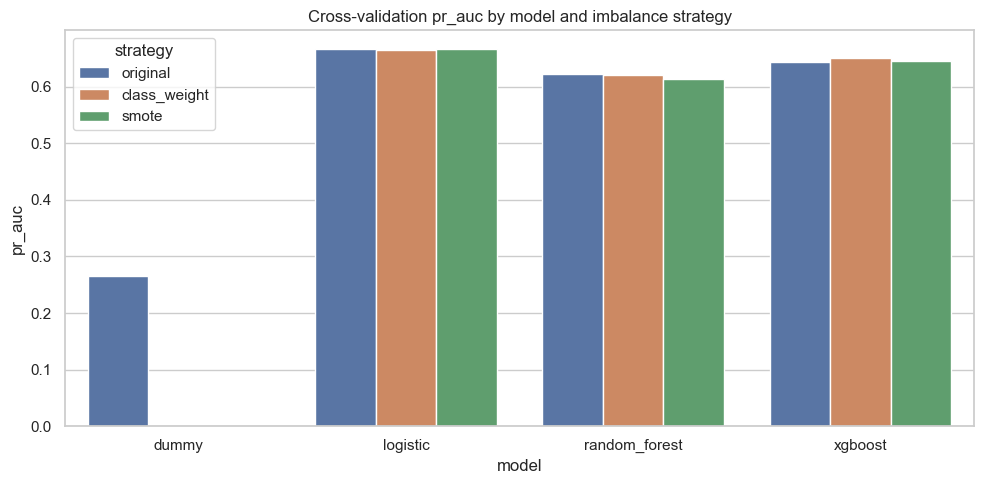

In [3]:
fig = evaluate.plot_model_comparison(results, metric="pr_auc")
fig.savefig(FIGURES_DIR / "model_comparison.png", dpi=120, bbox_inches="tight")

**Conclusion:**
- The **dummy** baseline scores PR-AUC ~0.265, which is just the churn base rate.
  Every real model clearly beats it.
- **Logistic Regression** has the highest cross-validation PR-AUC (~0.667),
  slightly ahead of XGBoost (~0.65) and Random Forest (~0.62).
- For every model, **class weights and SMOTE do not improve PR-AUC** over the
  original distribution - the differences are within the fold-to-fold noise.
  This is the leakage-safe SMOTE comparison the reference notebook never finished,
  and the honest result here is that SMOTE does not help on this dataset.

## 2. Tune the finalists and choose a model on the validation set

In [4]:
# For each model, take the imbalance strategy with the best cross-validation
# PR-AUC, then run a small grid search (scored by PR-AUC) on the training set.
best_strategy = (
    results[results["model"] != "dummy"]
    .sort_values("pr_auc", ascending=False)
    .drop_duplicates("model")
    .set_index("model")["strategy"]
    .to_dict()
)
print("Best strategy per model:", best_strategy)

param_grids = {
    "logistic": {"classifier__C": [0.1, 1.0, 10.0]},
    "random_forest": {
        "classifier__n_estimators": [200, 400],
        "classifier__max_depth": [None, 10, 20],
    },
    "xgboost": {
        "classifier__max_depth": [3, 5],
        "classifier__learning_rate": [0.05, 0.1],
        "classifier__n_estimators": [200, 400],
    },
}

tuned = {}
finalist_rows = []
for model_name, grid in param_grids.items():
    candidate = train.make_candidate(model_name, best_strategy[model_name], pos_weight)
    search = train.tune_model(candidate, grid, split.X_train, split.y_train)
    tuned[model_name] = search

    val_proba = search.predict_proba(split.X_val)[:, 1]
    metrics = evaluate.evaluate_predictions(split.y_val, val_proba)
    finalist_rows.append(
        {
            "model": model_name,
            "best_params": search.best_params_,
            "val_pr_auc": metrics["pr_auc"],
            "val_roc_auc": metrics["roc_auc"],
            "precision_at_80_recall": evaluate.precision_at_target_recall(
                split.y_val, val_proba, TARGET_RECALL
            ),
        }
    )

finalists = pd.DataFrame(finalist_rows)
finalists.round(3)

Best strategy per model: {'logistic': 'original', 'xgboost': 'class_weight', 'random_forest': 'original'}


,model,best_params,val_pr_auc,val_roc_auc,precision_at_80_recall
0,logistic,{'classifier__C': 10.0},0.643,0.837,0.500
1,random_forest,"{'classifier__max_depth': 10, 'classifier__n_e...",0.636,0.833,0.503
2,xgboost,"{'classifier__learning_rate': 0.05, 'classifie...",0.645,0.838,0.490


**Decision log - model selection**

- **What was tested:** Logistic Regression, Random Forest, and XGBoost, each
  tuned with a small grid on the training set, then scored on the validation set.
- **Primary metric (PR-AUC):** the three are almost identical on validation
  (XGBoost ~0.645, Logistic ~0.643, Random Forest ~0.636). The gaps are smaller
  than the cross-validation spread, so the top models are effectively tied.
- **Tie-breaker (precision at 80% recall):** among the two leaders, Logistic
  Regression gives higher precision at the recall we care about (~0.50) than
  XGBoost (~0.49).
- **Other considerations:** Logistic Regression is the simplest model, its
  probabilities are naturally well behaved, and its coefficients make Stage 4
  explanations straightforward.
- **Decision:** choose **Logistic Regression**. Random Forest and XGBoost are
  kept in the comparison for transparency but are not the better choice here.

## 3. Fit the chosen model and pick the decision threshold

In [5]:
# Use the tuned logistic pipeline. Fit on training data, then choose the
# threshold on the validation set so the choice is not made on the test set.
final_model = clone(tuned["logistic"].best_estimator_)
final_model.fit(split.X_train, split.y_train)

val_proba = final_model.predict_proba(split.X_val)[:, 1]
threshold = evaluate.threshold_for_target_recall(split.y_val, val_proba, TARGET_RECALL)
val_metrics = evaluate.evaluate_predictions(split.y_val, val_proba, threshold)

print("Chosen threshold (for >= 80% recall):", round(threshold, 3))
print("Validation metrics at this threshold:")
for key, value in val_metrics.items():
    print(f"  {key:10s} {value:.3f}")

Chosen threshold (for >= 80% recall): 0.243
Validation metrics at this threshold:
  threshold  0.243
  precision  0.500
  recall     0.805
  f1         0.617
  roc_auc    0.837
  pr_auc     0.643


In [6]:
# Overfitting check: compare train and validation PR-AUC.
train_proba = final_model.predict_proba(split.X_train)[:, 1]
train_pr_auc = evaluate.evaluate_predictions(split.y_train, train_proba)["pr_auc"]
print("Train PR-AUC:", round(train_pr_auc, 3))
print("Validation PR-AUC:", round(val_metrics["pr_auc"], 3))

Train PR-AUC: 0.676
Validation PR-AUC: 0.643


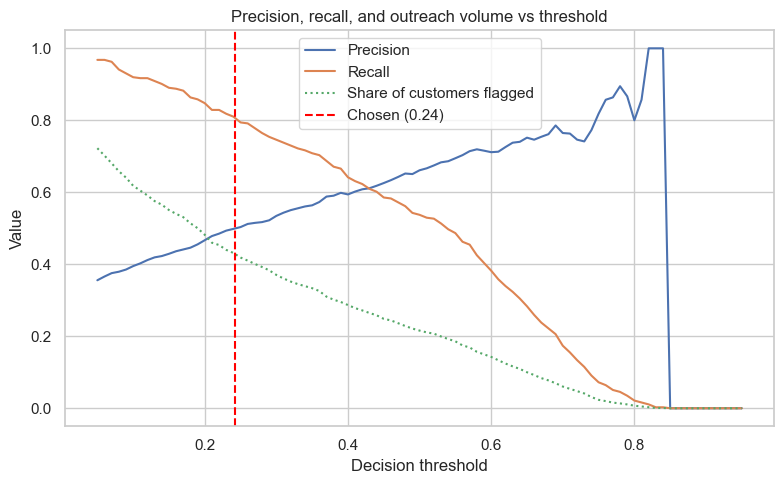

In [7]:
fig = evaluate.plot_threshold_analysis(split.y_val, val_proba, threshold)
fig.savefig(FIGURES_DIR / "threshold_analysis.png", dpi=120, bbox_inches="tight")

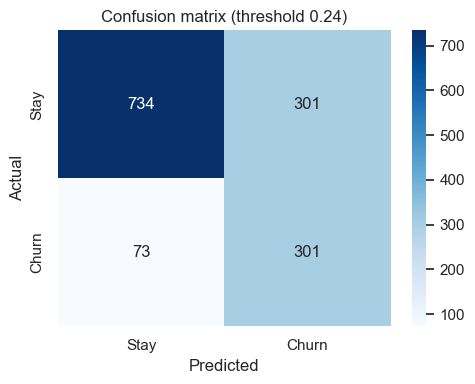

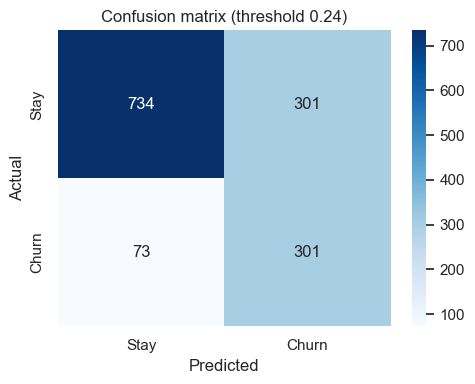

In [8]:
evaluate.plot_confusion_matrix(split.y_val, val_proba, threshold)

**Conclusion:** The threshold is about **0.24**, well below 0.5, which is what
we expect for a recall-leaning goal. At this threshold the model catches ~80% of
churners on validation with precision ~0.50, meaning roughly half of the customers
it flags really do churn. The train vs validation PR-AUC gap is small (~0.68 vs
~0.64), so the model is not overfitting.

## 4. Probability calibration

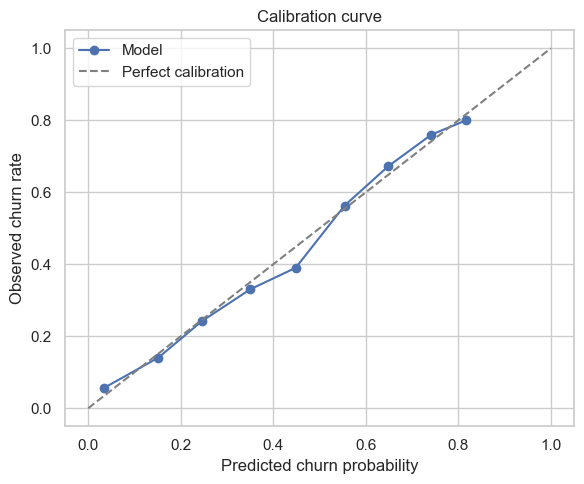

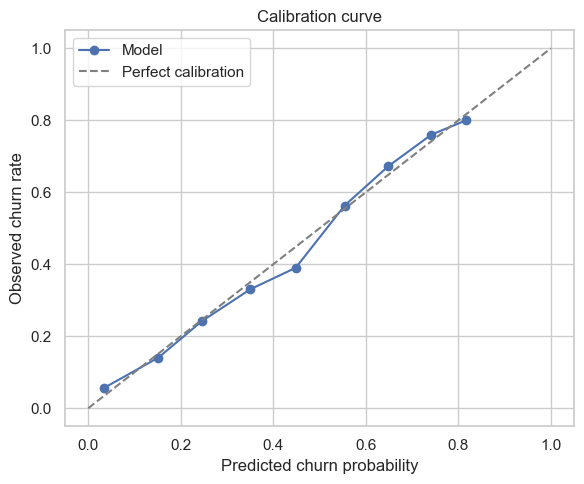

In [9]:
evaluate.plot_calibration(split.y_val, val_proba)

**Conclusion:** The reliability curve sits close to the diagonal, so the
predicted probabilities are reasonable as-is. We therefore do **not** add a
separate calibration step. Logistic Regression tends to produce well-calibrated
probabilities, which is helpful when the dashboard shows a churn percentage.

## 5. Final evaluation on the sealed test set (once)

In [10]:
# Now that the model and threshold are locked, refit on train + validation to
# use as much data as possible, then score the test set a single time.
X_train_val = pd.concat([split.X_train, split.X_val])
y_train_val = pd.concat([split.y_train, split.y_val])

deployment_model = clone(tuned["logistic"].best_estimator_)
deployment_model.fit(X_train_val, y_train_val)

test_proba = deployment_model.predict_proba(split.X_test)[:, 1]
test_metrics = evaluate.evaluate_predictions(split.y_test, test_proba, threshold)
print("Test metrics at the chosen threshold:")
for key, value in test_metrics.items():
    print(f"  {key:10s} {value:.3f}")

Test metrics at the chosen threshold:
  threshold  0.243
  precision  0.494
  recall     0.824
  f1         0.618
  roc_auc    0.841
  pr_auc     0.628


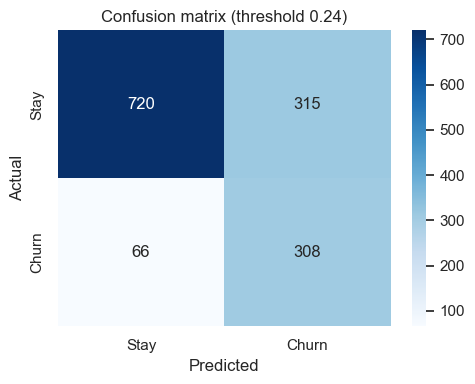

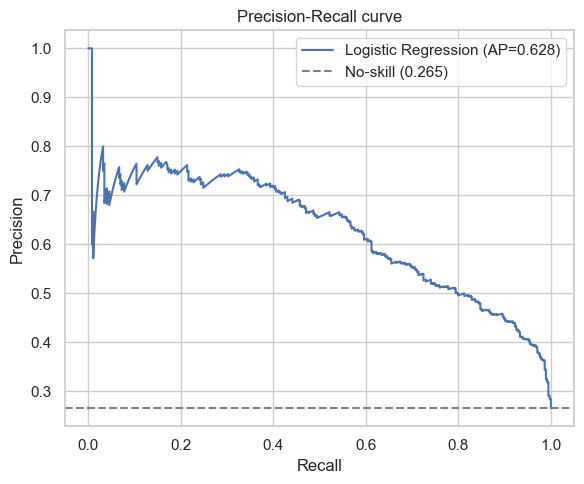

In [11]:
fig = evaluate.plot_confusion_matrix(split.y_test, test_proba, threshold)
fig.savefig(FIGURES_DIR / "confusion_matrix_test.png", dpi=120, bbox_inches="tight")

fig = evaluate.plot_precision_recall_curve(split.y_test, test_proba, label="Logistic Regression")
fig.savefig(FIGURES_DIR / "pr_curve_test.png", dpi=120, bbox_inches="tight")

**Conclusion:** On the untouched test set the model catches about **82% of
churners** (recall ~0.82) with precision ~0.49, flagging roughly 44% of customers
for outreach. The test numbers match validation closely, which means the model
generalises and the threshold choice holds up on unseen customers. For a retention
team, this is the intended trade-off: reach most at-risk customers, accept that
about half of the contacted customers would have stayed anyway.

## 6. Save the model and threshold

In [12]:
model_path = MODELS_DIR / "churn_model.joblib"
threshold_path = MODELS_DIR / "decision_threshold.json"

train.save_model(deployment_model, model_path)
threshold_path.write_text(
    json.dumps(
        {
            "model": "logistic_regression",
            "threshold": threshold,
            "target_recall": TARGET_RECALL,
        },
        indent=2,
    ),
    encoding="utf-8",
)

print("Saved model to:", model_path)
print("Saved threshold to:", threshold_path)

Saved model to: Q:\Customer Churn\customer-churn-retention\models\churn_model.joblib
Saved threshold to: Q:\Customer Churn\customer-churn-retention\models\decision_threshold.json


In [13]:
# Confirm the saved model loads in a fresh object and predicts the same way.
reloaded = train.load_model(model_path)
reloaded_proba = reloaded.predict_proba(split.X_test)[:, 1]
print("Reloaded model matches:", np.allclose(reloaded_proba, test_proba))

Reloaded model matches: True


## Summary of Stage 3

1. Built every model as a leakage-safe `imblearn` pipeline
   (preprocessor -> optional SMOTE -> classifier), so SMOTE only runs on training
   folds.
2. All real models beat the base-rate dummy. SMOTE and class weights did **not**
   improve PR-AUC on this dataset - a clear, honest comparison result.
3. Selected **Logistic Regression** using PR-AUC and precision-at-80%-recall, with
   the decision recorded.
4. Chose a recall-leaning threshold (~0.24) that catches ~80% of churners; the
   train/validation gap shows no overfitting and probabilities are well calibrated.
5. Sealed test set, scored once: recall ~0.82, precision ~0.49, ROC-AUC ~0.84.
6. Saved the deployment model (`churn_model.joblib`) and the threshold
   (`decision_threshold.json`); confirmed the saved model reloads identically.

**Next (Stage 4):** explain the model - global importance, permutation importance,
SHAP, and a plain-English per-customer breakdown of what raises or lowers risk.